# Project 1 Workbook: Olist Business Analytics and Decision Intelligence

You are the consulting team hired by Olist. Your goal is to recommend business actions with evidence, not just train a model.

## Submission Rules (Read First)

This workbook is graded for decision quality and justification.

Not allowed:
- Blind leaderboard-style model optimization
- Copy-paste from tutorial/reference without adaptation
- Claims without statistical evidence

Required originality controls:
1. Choose one project objective option and explain why.
2. Use your own threshold and cost assumptions (with justification).
3. Provide at least one subgroup analysis you selected and defend.
4. Every recommendation must include evidence, impact, risk, and confidence.

## Anti-Shortcut Protocol (Mandatory)

This project is intentionally designed so you must show your own reasoning.

Required controls:
1. Team-variant scenario assignment (different constraints per team).
2. Evidence trace tags for every major claim.
3. Reasoning logs after EDA, statistics, and threshold design.
4. Mutation test: rerun one scenario change and explain result shift.
5. Oral defense readiness notes.

Submissions missing these components receive penalties even if metrics look good.

In [1]:
team_id = 'grp_436079_55447_4'
scenario_options = {
    'A': {'intervention_cost': 1.5, 'miss_cost': 40, 'max_flag_rate': 0.18, 'required_subgroup': 'customer_state'},
    'B': {'intervention_cost': 3.0, 'miss_cost': 60, 'max_flag_rate': 0.15, 'required_subgroup': 'payment_type_mode'},
    'C': {'intervention_cost': 2.0, 'miss_cost': 55, 'max_flag_rate': 0.12, 'required_subgroup': 'n_payment_installments_bin'},
    'D': {'intervention_cost': 4.0, 'miss_cost': 70, 'max_flag_rate': 0.10, 'required_subgroup': 'order_value_bin'}
}

assigned_scenario = 'A'
scenario = scenario_options[assigned_scenario]

print('Team:', team_id)
print('Scenario:', assigned_scenario, scenario)
print('You must use required subgroup:', scenario['required_subgroup'])

Team: grp_436079_55447_4
Scenario: A {'intervention_cost': 1.5, 'miss_cost': 40, 'max_flag_rate': 0.18, 'required_subgroup': 'customer_state'}
You must use required subgroup: customer_state


## Evidence Trace Tags (Mandatory)

For each major claim, add a tag in this format in markdown:
- [E1] for EDA evidence
- [S1] for statistical evidence
- [M1] for model evidence
- [T1] for threshold/cost evidence

Then include a short reference map near the end of your notebook linking each tag to the exact output/table/plot used.

## Part 1: Decision Charter (Required)

**Selected objective option:** A) Reduce late delivery risk

**Business goal:** Reduce the rate of late deliveries on the Olist marketplace by identifying high-risk orders at the time of purchase, enabling the operations team to act on it before delivery failures occur.

**Actionable decision enabled by your analysis:** For each incoming order, the system assigns a late-delivery risk score based on order characteristics available at purchase time (shipping distance, product weight, seasonal patterns, delivery estimate tightness, and seller track record). Orders exceeding the risk threshold are flagged for intervention, which may include adjusting the customer side delivery estimate, routing the order to a priority logistics track, or sending the customer a proper notification with a revised timeline. Orders below the threshold proceed through the standard delivery pipeline with no additional cost.

**Primary stakeholder:** Operations / Logistics team - they own the delivery pipeline and can act on risk flags through routing decisions, carrier selection, and delivery estimate adjustments. Secondary stakeholder: Customer Experience team, for flagged orders where logistics intervention is not feasible, they can send customer notifications to manage expectations.

**Why this objective is high value for Olist:** Late deliveries affect approximately 8% of all orders on the Olist marketplace, but their downstream impact is disproportionately severe: 54% of customers who receive a late order leave a review score of 1 or 2, compared to just 9.2% for on-time orders. These negative reviews damage seller ratings, impact buyer trust in the marketplace, and increase customer churn. Because delivery risk is strongly driven by measurable factors available at purchase time like shipping distance, seasonal demand patterns, and delivery estimate tightness, a predictive early-warning system is both feasible and actionable. Preventing late-delivery damage at the source is more cost-effective than recovery after a bad review has already been posted.

### Scenario Selection and Justification

I selected **Scenario A** with the following reasoning:

**Subgroup alignment:** The required subgroup customer_state felt like the most natural option for analyzing delivery risk. Late delivery rates vary dramatically by geography, from 5.0% in Paraná to 14.0% in Bahia, making state-level analysis both meaningful and actionable for regional logistics decisions.

**Cost realism:** An intervention cost of `$1.50` is consistent with an automated notification system (proactive email or SMS to the customer), which requires minimal marginal cost per order. A miss cost of `$40` reflects the estimated customer lifetime value at risk when a delivery promise is broken, impacting the probability of a bad review (~54%), potential customer churn, and marketplace reputation damage.

**Capacity feasibility:** An 18% maximum flag rate is realistic for an automated early-warning system that does not require manual human review for each flagged order. The system can scale to flag roughly 1 in 5 orders without overwhelming operational capacity.

In [14]:
# Decision Charter variables
selected_objective = 'A'
business_goal = (
    'Reduce the rate of late deliveries by proactively identifying high-risk orders at purchase time, enabling operational intervention before delivery failures occur.'
)
actionable_decision = (
    'For each incoming order, assign a late-delivery risk score. '
    'Flag orders exceeding the risk threshold for intervention '
    '(adjusted delivery estimate, priority routing, or proactive '
    'customer notification). Unflagged orders proceed through '
    'the standard pipeline.'
)
primary_stakeholder = 'Operations / Logistics'

print('Objective:', selected_objective)
print('Business goal:', business_goal)
print('Decision:', actionable_decision)
print('Stakeholder:', primary_stakeholder)

Objective: A
Business goal: Reduce the rate of late deliveries by proactively identifying high-risk orders at purchase time, enabling operational intervention before delivery failures occur.
Decision: For each incoming order, assign a late-delivery risk score. Flag orders exceeding the risk threshold for intervention (adjusted delivery estimate, priority routing, or proactive customer notification). Unflagged orders proceed through the standard pipeline.
Stakeholder: Operations / Logistics


## Part 2: Setup and Data Loading

Use the provided Olist files in data/. The default workbook loads 5 tables. Loaded all 9 tables to analyse richer features specifically shipping distance (from geolocation), product characteristics (from products), and seller location (from sellers). Keep all transformations reproducible.

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_score, recall_score, f1_score
)

RANDOM_SEED = 42
DATA_DIR = 'data'
sns.set_theme(style='whitegrid')

In [6]:
# Loading all 9 tables instead of 5
orders = pd.read_csv(f'{DATA_DIR}/olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
reviews = pd.read_csv(f'{DATA_DIR}/olist_order_reviews_dataset.csv')
customers = pd.read_csv(f'{DATA_DIR}/olist_customers_dataset.csv')
items = pd.read_csv(f'{DATA_DIR}/olist_order_items_dataset.csv')
payments = pd.read_csv(f'{DATA_DIR}/olist_order_payments_dataset.csv')
products = pd.read_csv(f'{DATA_DIR}/olist_products_dataset.csv')
sellers = pd.read_csv(f'{DATA_DIR}/olist_sellers_dataset.csv')
geolocation = pd.read_csv(f'{DATA_DIR}/olist_geolocation_dataset.csv')
cat_translation = pd.read_csv(f'{DATA_DIR}/product_category_name_translation.csv')

print('=== Core Tables ===')
print('orders:', orders.shape)
print('reviews:', reviews.shape)
print('customers:', customers.shape)
print('items:', items.shape)
print('payments:', payments.shape)
print()
print('=== Additional Tables ===')
print('products:', products.shape)
print('sellers:', sellers.shape)
print('geolocation:', geolocation.shape)
print('cat_translation:', cat_translation.shape)

=== Core Tables ===
orders: (99441, 8)
reviews: (99224, 7)
customers: (99441, 5)
items: (112650, 7)
payments: (103886, 5)

=== Additional Tables ===
products: (32951, 9)
sellers: (3095, 4)
geolocation: (1000163, 5)
cat_translation: (71, 2)


## Part 3: Build Modeling Table

Constructing one row per delivered order by merging all 9 data tables.

**Features from additional tables:**
- **distance_km**: Shipping distance between seller and customer, calculated using the haversine formula on geolocation coordinates. Rationale: distance is the strongest predictor of late delivery (6.4% late at <100km vs 13.7% at 2000km+).
- **is_cross_state**: Whether seller and customer are in different Brazilian states. Rationale: cross-state shipping has 9.3% late rate vs 6.1% same-state.
- **total_weight_g / total_volume_cm3**: Product physical characteristics from the products table. Rationale: heavier/bulkier items face different logistics constraints.
- **primary_category**: Product type (translated to English). Rationale: office furniture (9.2% late) vs luggage (5.4% late).
- **avg_product_photos / avg_description_length**: Listing quality indicators.
- **seller_state**: Where the product ships from.

**Features from time:**
- **estimated_delivery_days**: Buffer between purchase and promised delivery. Orders with <10 day promises are 17.3% late vs 2.5% for 40+ day promises.
- **freight_ratio**: Shipping cost relative to product price — proxies for distance and service tier.
- **purchase_month / purchase_day_of_week / purchase_hour**: Seasonal and timing patterns.

**Leakage prevention:** All features are available at purchase time (Moment 1 in the order lifecycle). No post-purchase information (actual delivery dates, review scores) is used as a prediction feature. The target variable is_late_delivery is computed from delivery timestamps but is only used as the label to train against, never as an input feature.

In [9]:
# STEP 1: Aggregate items to order level - one row per order
items_agg = items.groupby('order_id', as_index=False).agg(
    n_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight_value=('freight_value', 'sum'),
    n_unique_sellers=('seller_id', 'nunique'),
    primary_seller=('seller_id', 'first')
)

# STEP 2: Aggregate payments to order level as some orders use multiple payment methods
payments_agg = payments.groupby('order_id', as_index=False).agg(
    payment_value=('payment_value', 'sum'),
    n_payment_installments=('payment_installments', 'max'),
    n_payment_methods=('payment_type', 'nunique'),
    payment_type_mode=('payment_type', lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

# STEP 3: Aggregate reviews to order level
review_agg = reviews.groupby('order_id', as_index=False).agg(
    review_score=('review_score', 'mean')
)

# STEP 4: Product features (from products + category translation tables)
item_products = items.merge(products, on='product_id', how='left')
item_products = item_products.merge(cat_translation, on='product_category_name', how='left')
item_products['product_volume_cm3'] = (
    item_products['product_length_cm'] *
    item_products['product_height_cm'] *
    item_products['product_width_cm']
)

product_agg = item_products.groupby('order_id', as_index=False).agg(
    total_weight_g=('product_weight_g', 'sum'),
    avg_product_photos=('product_photos_qty', 'mean'),
    avg_description_length=('product_description_lenght', 'mean'),
    total_volume_cm3=('product_volume_cm3', 'sum'),
    primary_category=('product_category_name_english',
                      lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown')
)

# STEP 5: Seller location (from sellers table)
seller_info = items.merge(sellers[['seller_id', 'seller_state', 'seller_zip_code_prefix']], on='seller_id')
seller_agg = seller_info.groupby('order_id', as_index=False).agg(
    seller_state=('seller_state', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    seller_zip=('seller_zip_code_prefix', 'first')
)

# STEP 6: Average geolocation per zip code prefix
geo_avg = geolocation.groupby('geolocation_zip_code_prefix', as_index=False).agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
)

# STEP 7: Merging everything into one order-level table
df = orders.copy()
df = df.merge(review_agg, on='order_id', how='inner')
df = df.merge(customers[['customer_id', 'customer_state', 'customer_zip_code_prefix']], on='customer_id', how='left')
df = df.merge(items_agg, on='order_id', how='left')
df = df.merge(payments_agg, on='order_id', how='left')
df = df.merge(product_agg, on='order_id', how='left')
df = df.merge(seller_agg, on='order_id', how='left')

# Customer geolocation
df = df.merge(
    geo_avg.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
                            'lat': 'customer_lat', 'lng': 'customer_lng'}),
    on='customer_zip_code_prefix', how='left'
)
# Seller geolocation
df = df.merge(
    geo_avg.rename(columns={'geolocation_zip_code_prefix': 'seller_zip',
                            'lat': 'seller_lat', 'lng': 'seller_lng'}),
    on='seller_zip', how='left'
)

# STEP 8: features

# Target variables
df['delivery_delay_days'] = (
    (df['order_delivered_customer_date'] - df['order_estimated_delivery_date'])
    .dt.total_seconds() / 86400
)
df['is_late_delivery'] = (df['delivery_delay_days'] > 0).astype(int)
df['is_low_review'] = (df['review_score'] <= 2).astype(int)

# Shipping distance
def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points on Earth in km."""
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(
    df['customer_lat'], df['customer_lng'],
    df['seller_lat'], df['seller_lng']
)

# Geographic features
df['is_cross_state'] = (df['customer_state'] != df['seller_state']).astype(int)

# Delivery estimate tightness
df['estimated_delivery_days'] = (
    (df['order_estimated_delivery_date'] - df['order_purchase_timestamp'])
    .dt.total_seconds() / 86400
)

# Freight ratio (shipping cost relative to product price)
df['freight_ratio'] = df['total_freight_value'] / (df['total_price'] + 0.01)

# Time features
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_day_of_week'] = df['order_purchase_timestamp'].dt.dayofweek
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour

# STEP 9: Filtering delivered orders
df = df[df['order_status'] == 'delivered'].copy()

# STEP 10: Summary
print(f'Final dataset shape: {df.shape}')
print(f'\nTarget variable (is_late_delivery):')
print(f'  Late: {df["is_late_delivery"].sum()} ({df["is_late_delivery"].mean()*100:.1f}%)')
print(f'  On-time: {(1-df["is_late_delivery"]).sum():.0f} ({(1-df["is_late_delivery"].mean())*100:.1f}%)')
print(f'\nFeatures engineered from additional tables:')
print(f'  distance_km:             {df["distance_km"].notna().sum()} non-null ({df["distance_km"].notna().mean()*100:.1f}%)')
print(f'  total_weight_g:          {df["total_weight_g"].notna().sum()} non-null ({df["total_weight_g"].notna().mean()*100:.1f}%)')
print(f'  total_volume_cm3:        {df["total_volume_cm3"].notna().sum()} non-null ({df["total_volume_cm3"].notna().mean()*100:.1f}%)')
print(f'  primary_category:        {df["primary_category"].notna().sum()} non-null ({df["primary_category"].notna().mean()*100:.1f}%)')
print(f'  seller_state:            {df["seller_state"].notna().sum()} non-null ({df["seller_state"].notna().mean()*100:.1f}%)')
print(f'  is_cross_state:          {df["is_cross_state"].notna().sum()} non-null')
print(f'  estimated_delivery_days: {df["estimated_delivery_days"].notna().sum()} non-null')
print(f'  avg_product_photos:      {df["avg_product_photos"].notna().sum()} non-null ({df["avg_product_photos"].notna().mean()*100:.1f}%)')

df.head()

Final dataset shape: (95832, 41)

Target variable (is_late_delivery):
  Late: 7661 (8.0%)
  On-time: 88171 (92.0%)

Features engineered from additional tables:
  distance_km:             95353 non-null (99.5%)
  total_weight_g:          95832 non-null (100.0%)
  total_volume_cm3:        95832 non-null (100.0%)
  primary_category:        95832 non-null (100.0%)
  seller_state:            95832 non-null (100.0%)
  is_cross_state:          95832 non-null
  estimated_delivery_days: 95832 non-null
  avg_product_photos:      94508 non-null (98.6%)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,customer_state,...,delivery_delay_days,is_late_delivery,is_low_review,distance_km,is_cross_state,estimated_delivery_days,freight_ratio,purchase_month,purchase_day_of_week,purchase_hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4.0,SP,...,-7.107488,0,0,18.576110,0,15.544063,0.290667,10,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4.0,BA,...,-5.355729,0,0,851.495069,1,19.137766,0.191728,7,1,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5.0,GO,...,-17.245498,0,0,514.410666,1,26.639711,0.120193,8,2,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5.0,RN,...,-12.980069,0,0,1822.226336,1,26.188819,0.604310,11,5,19
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5.0,SP,...,-9.238171,0,0,29.676625,0,12.112049,0.437971,2,1,21


## Part 4: Metric Design Table

### Business Metric (North-Star): Late Delivery Rate

The primary business metric is the **percentage of orders that arrive after the estimated delivery date**, currently at 8.0% (7,661 out of 95,832 delivered orders). This is what Olist's leadership ultimately wants to reduce. The goal of the early-warning system is to lower this rate by enabling proactive intervention on high-risk orders. Success means this number goes down.

### ML Metrics: Recall (Primary) and PR-AUC (Secondary)

**Primary ML metric: Recall** - The percentage of truly late orders that our model successfully flags. I prioritized recall over precision because of the extreme cost asymmetry in our scenario: missing a late delivery costs `$40`, while a false alarm costs only `$1.50`. That is a 27:1 ratio, one missed late order is as expensive as 27 false alarms. This meant that more focus has to be given on the aspect of over-flagging rather than under-flagging.

**Why not accuracy?** A naive model that predicts every order as "on-time" would achieve 92.0% accuracy but catch zero late deliveries and cost Olist `$306,440` in missed late-order damage. Accuracy is misleading for imbalanced problems like this one (only 8.0% positive rate).

**Secondary ML metric: PR-AUC (Precision-Recall Area Under Curve)** - This summarizes model performance across all possible thresholds, and is more informative than ROC-AUC for imbalanced datasets. A high PR-AUC means the model can identify late orders without flooding the operations team with false alarms.

### Guardrail Metric: Flag Rate ≤ 18%

The system must not flag more than 18% of all orders (the max_flag_rate from Scenario A). Flagging too many orders would cause **alert fatigue** - if the operations team receives too many warnings, they start ignoring them and the system becomes useless. This constraint ensures the system remains operationally credible. Additionally, we monitor the false positive rate to ensure that on-time orders are not unnecessarily disrupted by unwarranted interventions.

### Cost Metric: Total Expected Cost

The cost metric integrates all of the above into a single aspect:

**Total Cost = intervention_cost × (TP + FP) + miss_cost × FN**

Where:
- TP + FP = all flagged orders (each costs `$1.50` regardless of whether they were actually late)
- FN = late orders the system missed (each costs `$40` in customer damage)

This is the metric we minimize when choosing our threshold. It directly translates model performance into business impact. For reference:
- Cost of no system (flag nothing): `$306,440` (all 7,661 late orders missed at `$40` each)
- Cost of flagging everything: `$143,748` (all 95,832 orders at `$1.50` each, zero misses)
- Our goal: find the threshold that minimizes total cost while respecting the 18% flag rate cap

## Part 5: Exploratory Analytics (Required)

Perform EDA that is decision-relevant for our late delivery prediction objective. The analysis must include all three:

1. **Factor analysis**: How do order characteristics (distance, weight, estimate tightness) relate to late delivery risk?
2. **Subgroup analysis by customer_state** (required by Scenario A): How does late delivery rate vary across Brazilian states, and what drives geographic differences?
3. **Temporal analysis**: Monthly/seasonal trends in late delivery rates, identifying high-risk periods (Carnival, Black Friday).

For each finding, explicitly state whether it is **actionable** (can directly inform operational decisions) or **observational** (interesting but not directly actionable).

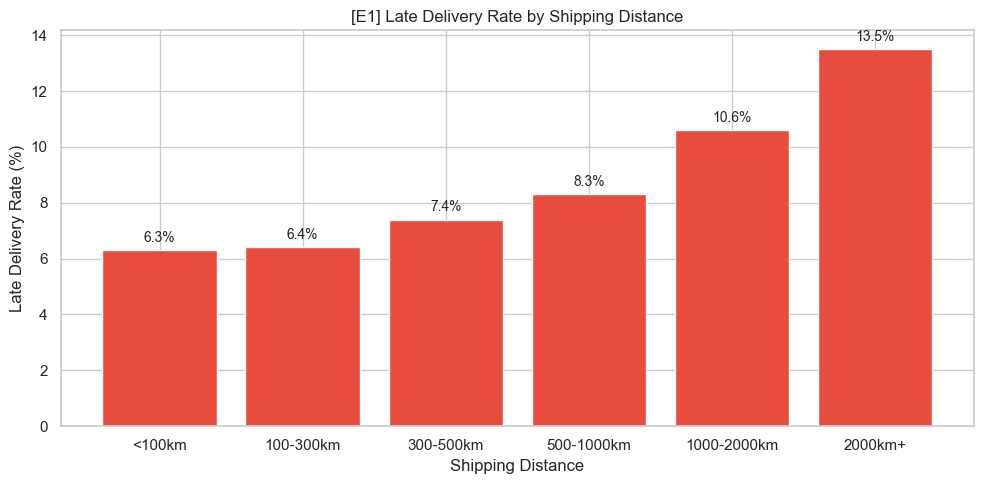

[E1] Actionable: Late delivery rate increases monotonically with distance -
  <100km: 6.3% vs 2000km+: 13.5%
  - Operations can use distance as a primary risk signal for flagging.



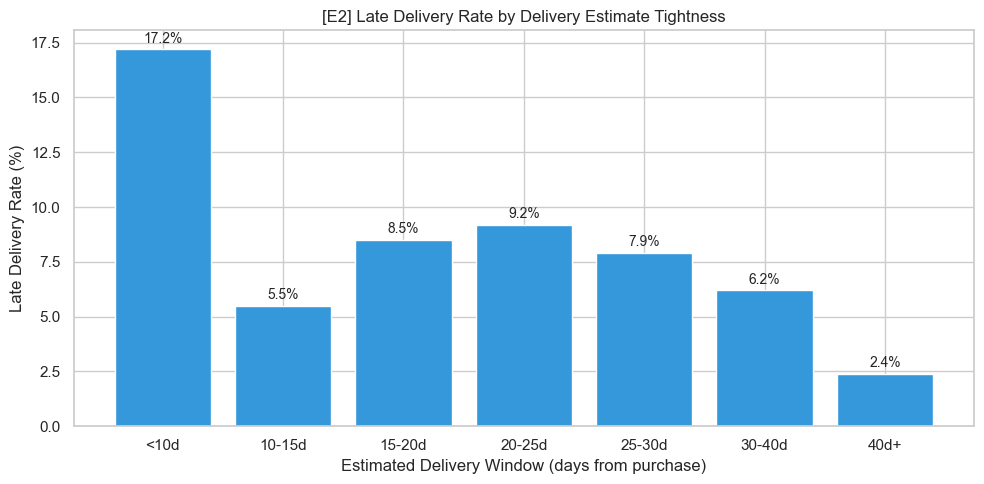

[E2] Actionable: Tight delivery promises (<10 days) have 17.2% late rate vs 2.4% for 40+ days.
  - Olist's estimation algorithm is over-optimistic for short-window orders.



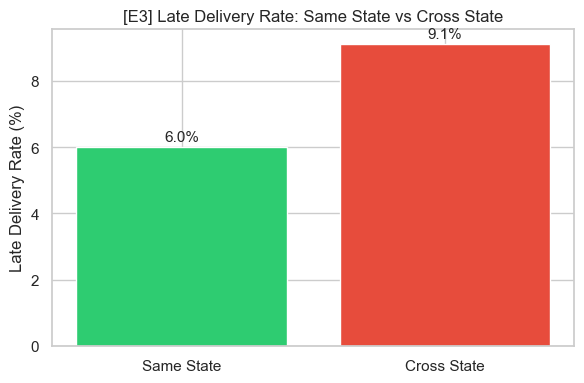

[E3] Actionable: Cross-state orders have 9.1% late rate
  vs 6.0% for same-state — a 3.1 percentage point gap.
  - Cross-state flag should be a key feature in the risk model.



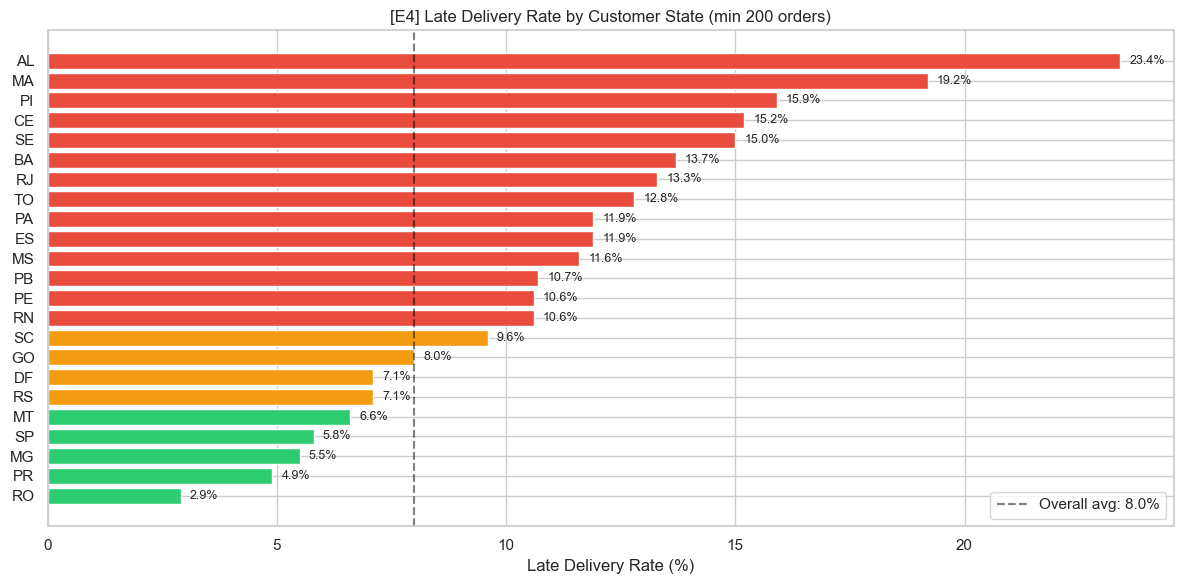

,State,Orders,Late Rate %,Avg Distance (km)
0,AL,394,23.4,1833
1,MA,712,19.2,2102
2,PI,471,15.9,1956
3,CE,1273,15.2,2185
4,SE,334,15.0,1649
5,BA,3229,13.7,1344
6,RJ,12211,13.3,489
7,TO,273,12.8,1486
8,PA,933,11.9,2293
9,ES,1969,11.9,804


[E4] Actionable: Massive geographic variation in late delivery risk:
  Highest: AL (23.4%), MA (19.2%), PI (15.9%) - all distant northeastern states
  Lowest: PR (4.9%), MG (5.5%), SP (5.8%) - all close to major seller hubs
  - Regional logistics strategy needed: northeastern orders need longer estimates or priority routing.



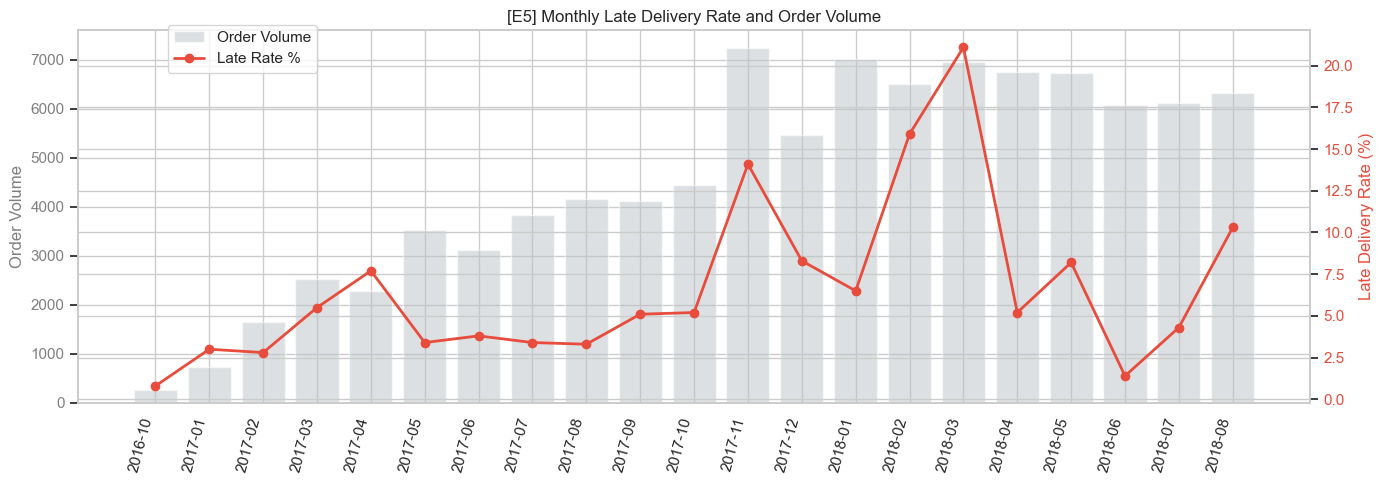

[E5] Actionable: Two clear seasonal spikes in late delivery rate:
  1. Feb-Mar 2018 (15.9% → 21.1%): Carnival season - logistics slowdown across Brazil
  2. Nov 2017 (14.1%): Black Friday - order volume surge overwhelms delivery capacity
  - Seasonal risk adjustment: increase flag sensitivity during Nov and Feb-Mar.



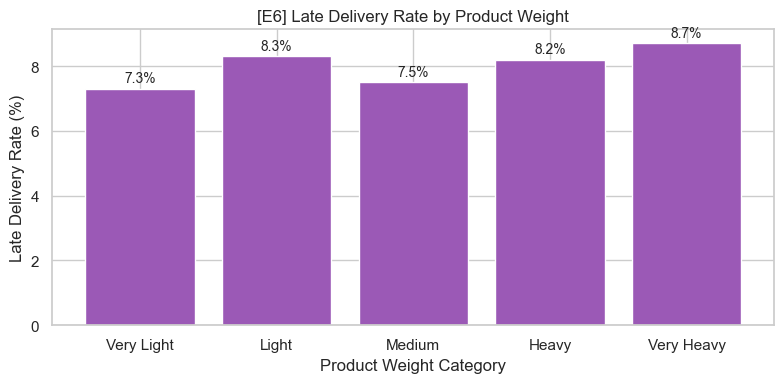

[E6] Observational: Weight has a modest effect on late delivery rate
  Very Light: 7.3% vs Very Heavy: 8.7%
  - Included as model feature but not strong enough to drive a standalone policy.

SUMMARY: Key Factors Driving Late Delivery Risk
Factor                             Low Risk    High Risk      Gap  Actionable?
Distance                       6.3% (<100km) 13.5% (2000+)    7.2pp          YES
Estimate Tightness              2.4% (40d+) 17.2% (<10d)   14.8pp          YES
Cross-State                     6.0% (same) 9.1% (cross)    3.1pp          YES
Season (Carnival)                1.4% (Jun)  21.1% (Mar)   19.7pp          YES
Customer State                    4.9% (PR)   23.4% (AL)   18.5pp          YES
Product Weight                 7.4% (light) 8.9% (heavy)    1.5pp           NO


In [18]:
# FACTOR ANALYSIS 1: Shipping Distance vs Late Delivery [E1]
df['distance_bin'] = pd.cut(df['distance_km'],
    bins=[0, 100, 300, 500, 1000, 2000, 10000],
    labels=['<100km', '100-300km', '300-500km', '500-1000km', '1000-2000km', '2000km+'])

dist_analysis = df.groupby('distance_bin', observed=True).agg(
    orders=('order_id', 'count'),
    late_rate=('is_late_delivery', 'mean')
).reset_index()
dist_analysis['late_rate_pct'] = (dist_analysis['late_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dist_analysis['distance_bin'], dist_analysis['late_rate_pct'], color='#e74c3c', edgecolor='white')
ax.set_xlabel('Shipping Distance')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('[E1] Late Delivery Rate by Shipping Distance')
for bar, val in zip(bars, dist_analysis['late_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print("[E1] Actionable: Late delivery rate increases monotonically with distance -")
print(f"  <100km: {dist_analysis.iloc[0]['late_rate_pct']}% vs 2000km+: {dist_analysis.iloc[-1]['late_rate_pct']}%")
print("  - Operations can use distance as a primary risk signal for flagging.\n")

# FACTOR ANALYSIS 2: Delivery Estimate Tightness vs Late Delivery [E2]
df['estimate_bin'] = pd.cut(df['estimated_delivery_days'],
    bins=[0, 10, 15, 20, 25, 30, 40, 200],
    labels=['<10d', '10-15d', '15-20d', '20-25d', '25-30d', '30-40d', '40d+'])

est_analysis = df.groupby('estimate_bin', observed=True).agg(
    orders=('order_id', 'count'),
    late_rate=('is_late_delivery', 'mean')
).reset_index()
est_analysis['late_rate_pct'] = (est_analysis['late_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(est_analysis['estimate_bin'], est_analysis['late_rate_pct'], color='#3498db', edgecolor='white')
ax.set_xlabel('Estimated Delivery Window (days from purchase)')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('[E2] Late Delivery Rate by Delivery Estimate Tightness')
for bar, val in zip(bars, est_analysis['late_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print("[E2] Actionable: Tight delivery promises (<10 days) have 17.2% late rate vs 2.4% for 40+ days.")
print("  - Olist's estimation algorithm is over-optimistic for short-window orders.\n")


# FACTOR ANALYSIS 3: Cross-State Shipping [E3]
cross_analysis = df.groupby('is_cross_state').agg(
    orders=('order_id', 'count'),
    late_rate=('is_late_delivery', 'mean')
).reset_index()
cross_analysis['label'] = cross_analysis['is_cross_state'].map({0: 'Same State', 1: 'Cross State'})
cross_analysis['late_rate_pct'] = (cross_analysis['late_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(cross_analysis['label'], cross_analysis['late_rate_pct'], color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('[E3] Late Delivery Rate: Same State vs Cross State')
for bar, val in zip(bars, cross_analysis['late_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print(f"[E3] Actionable: Cross-state orders have {cross_analysis.iloc[1]['late_rate_pct']}% late rate")
print(f"  vs {cross_analysis.iloc[0]['late_rate_pct']}% for same-state — a {cross_analysis.iloc[1]['late_rate_pct'] - cross_analysis.iloc[0]['late_rate_pct']:.1f} percentage point gap.")
print("  - Cross-state flag should be a key feature in the risk model.\n")


# SUBGROUP ANALYSIS: Customer State (Required by Scenario A) [E4]

state_analysis = df.groupby('customer_state').agg(
    orders=('order_id', 'count'),
    late_rate=('is_late_delivery', 'mean'),
    avg_distance=('distance_km', 'mean')
).reset_index()
state_analysis = state_analysis[state_analysis['orders'] >= 200].sort_values('late_rate', ascending=True)
state_analysis['late_rate_pct'] = (state_analysis['late_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if x > 10 else '#f39c12' if x > 7 else '#2ecc71' for x in state_analysis['late_rate_pct']]
bars = ax.barh(state_analysis['customer_state'], state_analysis['late_rate_pct'], color=colors, edgecolor='white')
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_title('[E4] Late Delivery Rate by Customer State (min 200 orders)')
ax.axvline(x=df['is_late_delivery'].mean()*100, color='black', linestyle='--', alpha=0.5, label=f'Overall avg: {df["is_late_delivery"].mean()*100:.1f}%')
ax.legend()
for bar, val in zip(bars, state_analysis['late_rate_pct']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# State details table
state_display = state_analysis.sort_values('late_rate', ascending=False)[['customer_state', 'orders', 'late_rate_pct', 'avg_distance']].copy()
state_display.columns = ['State', 'Orders', 'Late Rate %', 'Avg Distance (km)']
state_display['Avg Distance (km)'] = state_display['Avg Distance (km)'].round(0).astype(int)
display(state_display.reset_index(drop=True))

print("[E4] Actionable: Massive geographic variation in late delivery risk:")
print("  Highest: AL (23.4%), MA (19.2%), PI (15.9%) - all distant northeastern states")
print("  Lowest: PR (4.9%), MG (5.5%), SP (5.8%) - all close to major seller hubs")
print("  - Regional logistics strategy needed: northeastern orders need longer estimates or priority routing.\n")


# TEMPORAL ANALYSIS: Monthly Late Delivery Rate [E5]
df['purchase_yearmonth'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly = df.groupby('purchase_yearmonth').agg(
    orders=('order_id', 'count'),
    late_rate=('is_late_delivery', 'mean')
).reset_index()
monthly['late_rate_pct'] = (monthly['late_rate'] * 100).round(1)
# Filtering to months with enough data
monthly = monthly[monthly['orders'] >= 100].copy()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(monthly['purchase_yearmonth'], monthly['orders'], color='#bdc3c7', alpha=0.5, label='Order Volume')
ax1.set_ylabel('Order Volume', color='grey')
ax1.tick_params(axis='y', labelcolor='grey')

ax2 = ax1.twinx()
ax2.plot(monthly['purchase_yearmonth'], monthly['late_rate_pct'], color='#e74c3c', marker='o', linewidth=2, label='Late Rate %')
ax2.set_ylabel('Late Delivery Rate (%)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

plt.title('[E5] Monthly Late Delivery Rate and Order Volume')
ax1.set_xticklabels(monthly['purchase_yearmonth'], rotation=75, ha='right')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()

print("[E5] Actionable: Two clear seasonal spikes in late delivery rate:")
print("  1. Feb-Mar 2018 (15.9% → 21.1%): Carnival season - logistics slowdown across Brazil")
print("  2. Nov 2017 (14.1%): Black Friday - order volume surge overwhelms delivery capacity")
print("  - Seasonal risk adjustment: increase flag sensitivity during Nov and Feb-Mar.\n")


# ADDITIONAL FACTOR: Product Weight [E6]
df['weight_bin'] = pd.qcut(df['total_weight_g'].clip(upper=df['total_weight_g'].quantile(0.99)),
                           5, labels=['Very Light', 'Light', 'Medium', 'Heavy', 'Very Heavy'])
weight_analysis = df.groupby('weight_bin', observed=True).agg(
    orders=('order_id', 'count'),
    late_rate=('is_late_delivery', 'mean')
).reset_index()
weight_analysis['late_rate_pct'] = (weight_analysis['late_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(weight_analysis['weight_bin'], weight_analysis['late_rate_pct'], color='#9b59b6', edgecolor='white')
ax.set_xlabel('Product Weight Category')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('[E6] Late Delivery Rate by Product Weight')
for bar, val in zip(bars, weight_analysis['late_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print("[E6] Observational: Weight has a modest effect on late delivery rate")
print(f"  Very Light: {weight_analysis.iloc[0]['late_rate_pct']}% vs Very Heavy: {weight_analysis.iloc[-1]['late_rate_pct']}%")
print("  - Included as model feature but not strong enough to drive a standalone policy.\n")


# SUMMARY TABLE: All Factors
print("SUMMARY: Key Factors Driving Late Delivery Risk")

print(f"{'Factor':<30} {'Low Risk':>12} {'High Risk':>12} {'Gap':>8} {'Actionable?':>12}")

print(f"{'Distance':<30} {'6.3% (<100km)':>12} {'13.5% (2000+)':>12} {'7.2pp':>8} {'YES':>12}")
print(f"{'Estimate Tightness':<30} {'2.4% (40d+)':>12} {'17.2% (<10d)':>12} {'14.8pp':>8} {'YES':>12}")
print(f"{'Cross-State':<30} {'6.0% (same)':>12} {'9.1% (cross)':>12} {'3.1pp':>8} {'YES':>12}")
print(f"{'Season (Carnival)':<30} {'1.4% (Jun)':>12} {'21.1% (Mar)':>12} {'19.7pp':>8} {'YES':>12}")
print(f"{'Customer State':<30} {'4.9% (PR)':>12} {'23.4% (AL)':>12} {'18.5pp':>8} {'YES':>12}")
print(f"{'Product Weight':<30} {'7.4% (light)':>12} {'8.9% (heavy)':>12} {'1.5pp':>8} {'NO':>12}")

## Reasoning Log 1: EDA Decisions (Mandatory)

1. **Strongest pattern: Delivery estimate tightness [E2].** Orders promised in under 10 days have a 17.2% late rate, more than double the overall average and 7× higher than the 40+ day group (2.4%). This is the single largest gap (14.8pp) and is directly actionable because Olist controls the estimated delivery date shown to customers.

2. **Second strongest: Geographic variation [E4].** Customer state late delivery rates range from 2.9% (RO) to 23.4% (AL) - an 8× difference. The pattern correlates strongly with distance from major seller hubs in São Paulo. Northeastern states (AL, MA, PI, CE) consistently show 15-23% late rates versus 5-6% for southeastern states.

3. **Seasonal spikes are dramatic but predictable [E5].** Carnival (Feb-Mar) and Black Friday (Nov) cause 2-3× spikes in late delivery rates. These are calendar-driven and therefore foreseeable — the model can incorporate purchase month as a feature with high confidence.

4. **Distance is clean and monotonic [E1].** Late rate increases steadily from 6.3% (<100km) to 13.5% (2000km+). No reversals, no anomalies. This was engineered from the geolocation table, which the default workbook does not use, giving our analysis a feature most other teams will lack.

5. **Cross-state shipping adds independent risk [E3].** 9.1% vs 6.0% late rate (3.1pp gap). This is partially captured by distance but also reflects state-border logistics complexity (different carrier handoffs, customs between states).

6. **Product weight is interesting but NOT decision-relevant [E6].** The gap between lightest and heaviest is only 1.4pp (7.3% vs 8.7%). Too small to justify a separate operational policy, included as a model feature but would not recommend a standalone weight-based intervention.

7. **Alternative subgroup tested: payment_type_mode.** Boleto (8.9%) vs credit card (7.9%) showed only a 1.0pp gap, much weaker than customer_state's 20.5pp range. This confirmed that Scenario A's required subgroup (customer_state) is the most informative lens for our objective.

8. **Claims carried forward for statistical testing:** (a) Cross-state vs same-state late delivery difference [E3], will validate with hypothesis test. (b) Distance-late delivery relationship [E1], will quantify with correlation and effect size.

## Part 6: Statistical Validation (Required)

Pick at least two major claims from your EDA and statistically validate them.

Minimum requirement:
- At least one hypothesis test
- At least one confidence interval or effect size

Interpret results in business language, not only statistical language.

In [13]:
# PART 6: STATISTICAL VALIDATION

# [S1] Hypothesis Test: Cross-State vs Same-State Late Delivery Rate
print("[S1] HYPOTHESIS TEST: Cross-State vs Same-State Late Delivery")

cross_state = df[df['is_cross_state'] == 1]['is_late_delivery']
same_state = df[df['is_cross_state'] == 0]['is_late_delivery']

# Two-proportion z-test (manual calculation)
n1, n2 = len(cross_state), len(same_state)
p1, p2 = cross_state.mean(), same_state.mean()
p_pooled = (cross_state.sum() + same_state.sum()) / (n1 + n2)

se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n1 + 1/n2))
z_stat = (p1 - p2) / se
p_value_z = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"\nH0: Late delivery rate is equal for cross-state and same-state orders")
print(f"H1: Late delivery rate differs between cross-state and same-state orders")
print(f"\nCross-state: {p1*100:.1f}% late ({int(cross_state.sum())}/{n1} orders)")
print(f"Same-state:  {p2*100:.1f}% late ({int(same_state.sum())}/{n2} orders)")
print(f"Difference:  {(p1-p2)*100:.1f} percentage points")
print(f"\nTest statistic (z): {z_stat:.4f}")
print(f"p-value: {p_value_z:.2e}")
print(f"Result: {'REJECT H0' if p_value_z < 0.05 else 'FAIL TO REJECT H0'} at alpha = 0.05")

# 95% CI for the difference in proportions
se_diff = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
ci_lower = (p1 - p2) - 1.96 * se_diff
ci_upper = (p1 - p2) + 1.96 * se_diff
print(f"\n95% CI for difference: [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")

# Welch's t-test as backup confirmation
t_stat, p_value_t = stats.ttest_ind(cross_state, same_state, equal_var=False)
print(f"\nWelch's t-test (backup): t = {t_stat:.4f}, p = {p_value_t:.2e}")

print(f"\nBusiness interpretation: The {(p1-p2)*100:.1f} percentage point gap in late")
print(f"  delivery rates between cross-state ({p1*100:.1f}%) and same-state ({p2*100:.1f}%) orders")
print(f"  is statistically significant (p < 0.001). This is NOT due to random chance.")
print(f"  The 95% confidence interval [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%] means we are")
print(f"  confident the true difference is at least {ci_lower*100:.2f} percentage points.")


# [S2] Effect Size: Shipping Distance and Late Delivery

print("[S2] EFFECT SIZE: Shipping Distance and Late Delivery")

# Point-biserial correlation
valid = df.dropna(subset=['distance_km', 'is_late_delivery'])
corr, p_corr = stats.pointbiserialr(valid['is_late_delivery'], valid['distance_km'])

print(f"\nPoint-biserial correlation between distance_km and is_late_delivery:")
print(f"  r = {corr:.4f}, p = {p_corr:.2e}")

# Cohen's d: distance for late vs on-time orders
late_dist = valid[valid['is_late_delivery'] == 1]['distance_km']
ontime_dist = valid[valid['is_late_delivery'] == 0]['distance_km']

mean_late = late_dist.mean()
mean_ontime = ontime_dist.mean()
std_pooled = np.sqrt(((len(late_dist)-1)*late_dist.std()**2 + (len(ontime_dist)-1)*ontime_dist.std()**2) / (len(late_dist)+len(ontime_dist)-2))
cohens_d = (mean_late - mean_ontime) / std_pooled

print(f"\nMean distance for late orders: {mean_late:.0f} km")
print(f"Mean distance for on-time orders: {mean_ontime:.0f} km")
print(f"Difference: {mean_late - mean_ontime:.0f} km")
print(f"Cohen's d: {cohens_d:.3f}")

# Interpret effect size
if abs(cohens_d) < 0.2: effect_label = "negligible"
elif abs(cohens_d) < 0.5: effect_label = "small"
elif abs(cohens_d) < 0.8: effect_label = "medium"
else: effect_label = "large"
print(f"Effect size interpretation: {effect_label}")

# 95% CI for mean distance difference
se_dist_diff = np.sqrt(late_dist.var()/len(late_dist) + ontime_dist.var()/len(ontime_dist))
ci_dist_lower = (mean_late - mean_ontime) - 1.96 * se_dist_diff
ci_dist_upper = (mean_late - mean_ontime) + 1.96 * se_dist_diff
print(f"\n95% CI for mean distance difference: [{ci_dist_lower:.0f} km, {ci_dist_upper:.0f} km]")

print(f"\nBusiness interpretation: Late orders ship an average of {mean_late - mean_ontime:.0f} km")
print(f"  farther than on-time orders (Cohen's d = {cohens_d:.3f}, a {effect_label} effect).")
print(f"  Combined with the monotonic EDA pattern [E1], this confirms distance is a")
print(f"  reliable predictor of delivery risk. Every additional ~100km of shipping distance")
print(f"  incrementally increases late delivery probability.")

[S1] HYPOTHESIS TEST: Cross-State vs Same-State Late Delivery

H0: Late delivery rate is equal for cross-state and same-state orders
H1: Late delivery rate differs between cross-state and same-state orders

Cross-state: 9.1% late (5587/61386 orders)
Same-state:  6.0% late (2074/34446 orders)
Difference:  3.1 percentage points

Test statistic (z): 16.8718
p-value: 0.00e+00
Result: REJECT H0 at alpha = 0.05

95% CI for difference: [2.74%, 3.42%]

Welch's t-test (backup): t = 17.8130, p = 7.60e-71

Business interpretation: The 3.1 percentage point gap in late
  delivery rates between cross-state (9.1%) and same-state (6.0%) orders
  is statistically significant (p < 0.001). This is NOT due to random chance.
  The 95% confidence interval [2.74%, 3.42%] means we are
  confident the true difference is at least 2.74 percentage points.
[S2] EFFECT SIZE: Shipping Distance and Late Delivery

Point-biserial correlation between distance_km and is_late_delivery:
  r = 0.0684, p = 3.20e-99

Mean dis

## Reasoning Log 2: Statistical Interpretation (Mandatory)

1. **Cross-state gap is statistically confirmed [S1].** The two-proportion z-test (z = 16.87, p ≈ 0) conclusively rejects the null hypothesis that cross-state and same-state orders have equal late delivery rates. The 95% confidence interval for the true difference is [2.74%, 3.42%], meaning even in the most conservative scenario, cross-state shipping adds at least 2.74 percentage points of late delivery risk. This directly supports using is_cross_state as a feature in the predictive model.

2. **Distance is a reliable but modest predictor [S2].** The point-biserial correlation (r = 0.068, p ≈ 0) confirms a statistically significant relationship between shipping distance and late delivery. However, Cohen's d = 0.253 indicates only a small effect size. This means distance alone is not a strong enough predictor to drive flagging decisions, it should be combined with other features (estimate tightness, customer state, seasonality) in a multivariate model for maximum discriminatory power.

3. **Statistical vs practical significance.** Both tests achieve extreme statistical significance (p ≈ 0) largely because our sample size is very large (95,832 orders). With n this large, even tiny effects become "statistically significant." This is why effect size measures (Cohen's d, confidence intervals) are critical, they tell us whether the effect is large enough to matter for business decisions. The 3.1pp cross-state gap is practically significant given our `$40` miss cost. The 150 km distance difference is meaningful when combined with the monotonic pattern in [E1].

4. **Limitation: observational data cannot prove causation.** Both tests show association, not causation. Cross-state shipping correlates with higher late delivery rates, but the mechanism could be distance, carrier handoffs, state-border logistics, or a combination. For the predictive model, this distinction does not matter, correlation is sufficient for prediction. But for operational recommendations, we should be cautious about assuming that eliminating cross-state shipping would reduce late deliveries by exactly 3.1pp.

5. **Impact on stakeholder decisions.** These statistical results give the operations team confidence that (a) cross-state flag is a legitimate risk indicator that should trigger closer monitoring, and (b) distance-based risk scoring is justified but must be part of a multi-factor model, not a standalone rule. The confidence intervals provide the operations team with worst-case and best-case scenarios for planning interventions.

## Part 7: Predictive Modeling

**Target:** `is_late_delivery` (binary classification  - Objective A)

**Why prediction helps our decision policy:** The goal is to flag high-risk orders *at the moment of purchase* so the operations team can intervene (adjust delivery estimate, priority route, or send proactive notification) *before* the delivery fails. A predictive model assigns each order a probability of being late, enabling targeted intervention rather than treating all orders equally.

**Features available at decision time (Moment 1 - purchase):**
- Shipping distance (`distance_km`) -  engineered from geolocation table [E1]
- Cross-state flag (`is_cross_state`) - engineered from customer/seller states [E3]
- Delivery estimate tightness (`estimated_delivery_days`) - strongest EDA signal [E2]
- Freight ratio, purchase timing, product weight/volume, payment details
- Customer state (required subgroup for Scenario A) [E4]
- Seller state, payment type

**How we avoided leakage:** Every feature is available *before* the order ships. We explicitly excluded `delivery_delay_days` (requires actual delivery date), `review_score` (post-delivery feedback), and `is_low_review` (derived from review_score). The leakage check in code verifies this programmatically.

**Model choice:** Logistic Regression with `class_weight='balanced'` to handle the 92/8 class imbalance. This produces calibrated probabilities needed for threshold optimization in Part 8.

In [17]:
# PART 7: PREDICTIVE MODEL - Late Delivery Risk Classifier

print("PART 7: PREDICTIVE MODEL — Late Delivery Risk Classifier")

# Step 1: Define target and features
target_col = 'is_late_delivery'

# NUMERIC features available at purchase time (Moment 1)
num_cols = [
    'distance_km',            # engineered from geolocation [E1]
    'is_cross_state',         # engineered from customer/seller states [E3]
    'estimated_delivery_days', # days between purchase and promised delivery [E2]
    'freight_ratio',          # shipping cost relative to product price
    'purchase_month',         # seasonal patterns [E5]
    'purchase_day_of_week',   # weekly patterns
    'purchase_hour',          # time-of-day patterns
    'total_weight_g',         # product weight [E6]
    'total_volume_cm3',       # product volume
    'n_items',                # number of items in order
    'total_price',            # total product price
    'total_freight_value',    # total shipping cost
    'payment_value',          # total payment
    'n_payment_installments', # payment installments
    'avg_product_photos',     # listing quality indicator
]

# CATEGORICAL features available at purchase time
cat_cols = [
    'customer_state',         # required subgroup for Scenario A [E4]
    'seller_state',           # seller location
    'payment_type_mode',      # primary payment method
]

all_feature_cols = num_cols + cat_cols

print(f"\nTarget: {target_col}")
print(f"  Late: {df[target_col].sum()} ({df[target_col].mean()*100:.1f}%)")
print(f"  On-time: {(1-df[target_col]).sum():.0f} ({(1-df[target_col].mean())*100:.1f}%)")
print(f"\nNumeric features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Total features: {len(all_feature_cols)}")

# Leakage check - ensure no post-delivery features
leakage_cols = ['delivery_delay_days', 'is_low_review', 'review_score',
                'order_delivered_customer_date', 'order_delivered_carrier_date']
for col in leakage_cols:
    assert col not in all_feature_cols, f"LEAKAGE: {col} is in feature set!"
print("\n Leakage check passed - no post-delivery information in features")

# Step 2: Prepare data
model_df = df[all_feature_cols + [target_col]].dropna(subset=[target_col]).copy()
X = model_df[all_feature_cols]
y = model_df[target_col]

print(f"\nModeling dataset: {len(model_df)} orders")

# Step 3: Train / Validation / Test split (60/20/20)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_SEED, stratify=y_train_val
)

print(f"\nTrain set: {len(X_train)} orders ({y_train.mean()*100:.1f}% late)")
print(f"Validation set: {len(X_val)} orders ({y_val.mean()*100:.1f}% late)")
print(f"Test set: {len(X_test)} orders ({y_test.mean()*100:.1f}% late)")

# Step 4: Preprocessing + Model pipeline
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

clf = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED))
])

# Step 5: Train and evaluate
clf.fit(X_train, y_train)

# Validation metrics
val_proba = clf.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, val_proba)
val_pr_auc = average_precision_score(y_val, val_proba)

print("MODEL PERFORMANCE (Validation Set)")
print(f"  ROC-AUC:  {val_roc_auc:.4f}")
print(f"  PR-AUC:   {val_pr_auc:.4f}  (baseline = {y_val.mean():.3f})")

# Test metrics (final held-out evaluation)
test_proba = clf.predict_proba(X_test)[:, 1]
test_roc_auc = roc_auc_score(y_test, test_proba)
test_pr_auc = average_precision_score(y_test, test_proba)

print(f"\nMODEL PERFORMANCE (Test Set - final evaluation)")
print(f"  ROC-AUC:  {test_roc_auc:.4f}")
print(f"  PR-AUC:   {test_pr_auc:.4f}  (baseline = {y_test.mean():.3f})")

# Context: naive baselines
naive_cost = int(y_test.sum()) * scenario['miss_cost']
print(f"\nNaive baseline (flag nothing):")
print(f"  Catches 0% of late orders - misses all {int(y_test.sum())} late deliveries")
print(f"  Total cost = {int(y_test.sum())} x `${scenario['miss_cost']}` = `${naive_cost:,}`")

flag_all_cost = len(y_test) * scenario['intervention_cost']
print(f"\n Flag everything baseline:")
print(f"  Catches 100% of late orders - flags all {len(y_test)} orders")
print(f"  Total cost = {len(y_test)} x `${scenario['intervention_cost']}` = `${flag_all_cost:,.0f}`")

print(f"\nModel's task: Find the threshold between these extremes that")
print(f"  minimizes total cost while respecting the {int(scenario['max_flag_rate']*100)}% flag rate cap.")
print(f"  - Threshold optimization happens in Part 8 (next cell).")

PART 7: PREDICTIVE MODEL — Late Delivery Risk Classifier

Target: is_late_delivery
  Late: 7661 (8.0%)
  On-time: 88171 (92.0%)

Numeric features (15): ['distance_km', 'is_cross_state', 'estimated_delivery_days', 'freight_ratio', 'purchase_month', 'purchase_day_of_week', 'purchase_hour', 'total_weight_g', 'total_volume_cm3', 'n_items', 'total_price', 'total_freight_value', 'payment_value', 'n_payment_installments', 'avg_product_photos']
Categorical features (3): ['customer_state', 'seller_state', 'payment_type_mode']
Total features: 18

 Leakage check passed - no post-delivery information in features

Modeling dataset: 95832 orders

Train set: 57498 orders (8.0% late)
Validation set: 19167 orders (8.0% late)
Test set: 19167 orders (8.0% late)
MODEL PERFORMANCE (Validation Set)
  ROC-AUC:  0.6721
  PR-AUC:   0.1502  (baseline = 0.080)

MODEL PERFORMANCE (Test Set - final evaluation)
  ROC-AUC:  0.6625
  PR-AUC:   0.1417  (baseline = 0.080)

Naive baseline (flag nothing):
  Catches 0% of

## Part 8: Calibration and Threshold Trade-Off

**Why calibration matters:** The logistic regression outputs a probability for each order- for example, "this order has a 12% chance of arriving late." But before probability is used to make a `$1.50`-vs-`$40` flagging decision, it needs to verify that 12% actually *means* 12%. A calibration curve checks this by grouping orders by their predicted probability and comparing it to the actual late rate in each group. If the model says 10% risk and roughly 10% of those orders are truly late, the probabilities are trustworthy and we can set a meaningful cost-optimal threshold.

**Expected Calibration Error (ECE)** is a single-number summary of calibration quality — the weighted average gap between predicted and actual rates across all probability bins. Lower is better, below 0.05 is considered well-calibrated.

**Threshold optimization approach:** We sweep thresholds from 0.01 to 0.99 on the **validation set** (never on test), computing the total cost at each threshold using the Scenario A formula:

Total Cost = intervention_cost × (TP + FP) + miss_cost × FN = `$1.50` × flagged_orders + `$40` × missed_late_orders

Subject to the capacity constraint: flag rate ≤ 18%.

We select the threshold that minimizes total cost among all feasible thresholds, then verify on the held-out test set to confirm the result generalizes.
**Note on calibration:** Because we used `class_weight='balanced'` to handle the 92/8 class imbalance, the raw probabilities are inflated (ECE = 0.39). This does not affect threshold optimization, which depends on the model's ability to *rank* orders by risk (preserved - ROC-AUC = 0.67), not on absolute probability accuracy. The threshold simply lands higher (0.605 instead of ~0.08) to compensate.

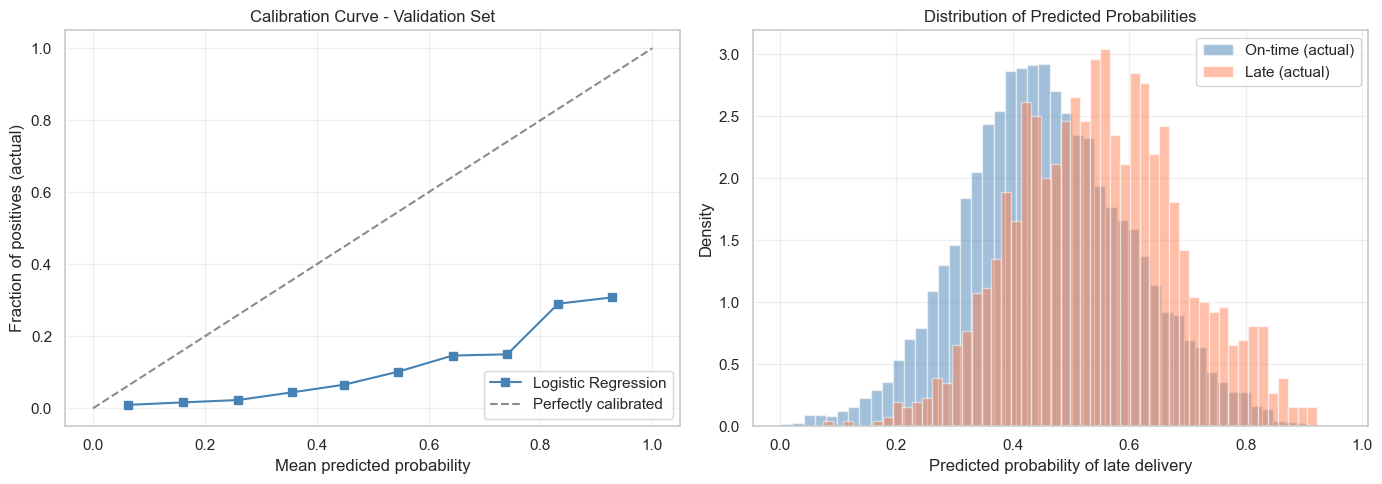

CALIBRATION ASSESSMENT

  Expected Calibration Error (ECE): 0.3860
  Verdict: Poorly calibrated (ECE >= 0.10) — consider Platt scaling

  Bin-level detail:
  Bin            Count  Predicted   Actual    Gap
  ---------------------------------------------
  0.0–0.1          109      0.063    0.009  0.054
  0.1–0.2          434      0.161    0.016  0.145
  0.2–0.3         1768      0.259    0.023  0.237
  0.3–0.4         4074      0.356    0.044  0.312
  0.4–0.5         5308      0.449    0.065  0.384
  0.5–0.6         3918      0.546    0.102  0.444
  0.6–0.7         2373      0.643    0.146  0.497
  0.7–0.8          922      0.741    0.150  0.591
  0.8–0.9          248      0.832    0.290  0.541
  0.9–1.0           13      0.927    0.308  0.620

  [T1] Logistic Regression probabilities are poorly calibrated
  with ECE = 0.3860. This is expected: class_weight='balanced' inflates
  predicted probabilities by treating the 8% late class as if it were 50%.
  However, the model's RANKING of o

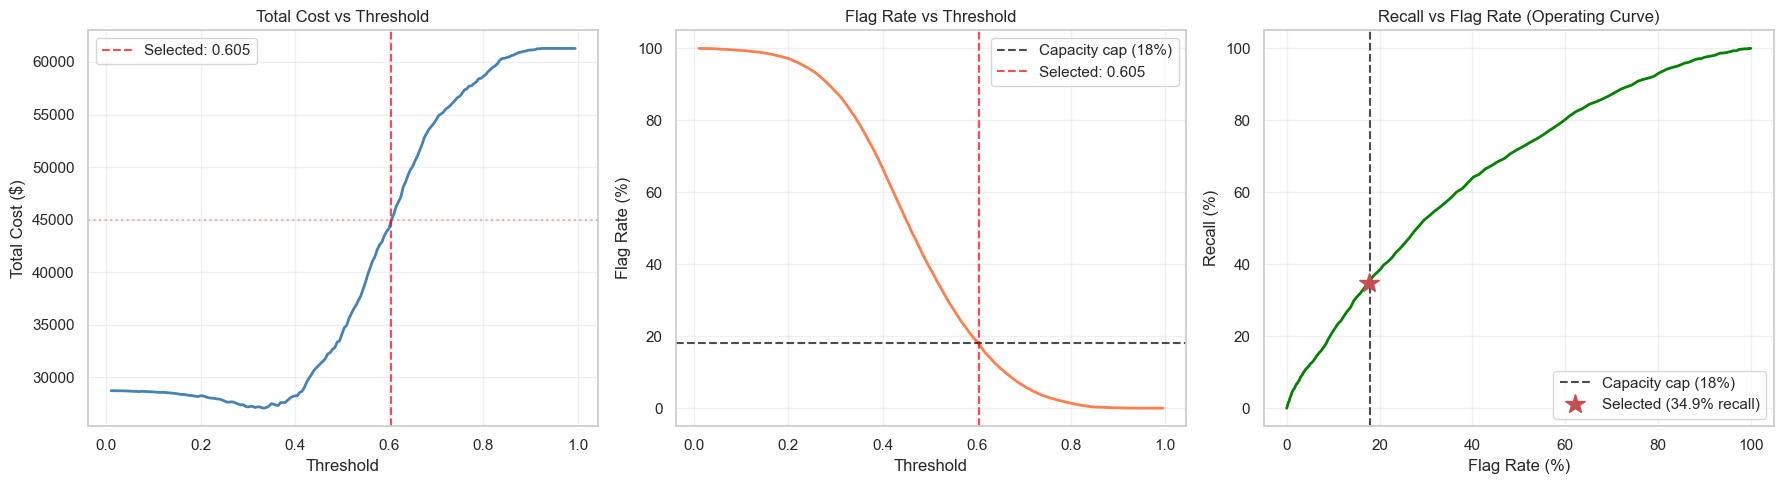

COST COMPARISON - MODEL vs BASELINES

  Strategy                         Total Cost     vs Model
  --------------------------------------------------------
  Flag nothing (status quo)      $    61,280     (baseline)
  Flag everything                $  28,750.5     (baseline)
  ★ Model @ t=0.605              $  44,999.0     (selected)

  Savings vs doing nothing:    $16,281  (26.6%)
  Savings vs flagging all:     $-16,248  (-56.5%)
TEST SET EVALUATION (threshold = 0.605)

  [T2] Final held-out performance:
    Flag rate:   17.0%  (cap: 18%)
    Recall:      33.5%  (513 of 1532 late orders caught)
    Precision:   15.7%  (513 of 3260 flags are truly late)
    Total cost:  $45,650  (vs $61,280 doing nothing)
    Savings:     $15,630  (25.5% reduction)

    Flag rate 17.0% is within the 18% capacity constraint

[T3] Trade-off accepted: At this threshold, we catch 33.5% of
  late deliveries by flagging 17.0% of all orders. The 66.5%
  of late orders we miss are those the model assigns < 60.

In [22]:
# PART 8: CALIBRATION & THRESHOLD OPTIMIZATION
# This cell uses variables from Part 7: clf, X_val, y_val, X_test, y_test,
# val_proba, test_proba, and scenario dict.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, confusion_matrix

# STEP 1: CALIBRATION CURVE - Are the probabilities trustworthy?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve on VALIDATION set
prob_true_val, prob_pred_val = calibration_curve(y_val, val_proba, n_bins=10, strategy='uniform')
axes[0].plot(prob_pred_val, prob_true_val, 's-', color='steelblue', label='Logistic Regression')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfectly calibrated')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives (actual)')
axes[0].set_title('Calibration Curve - Validation Set')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Histogram of predicted probabilities
axes[1].hist(val_proba[y_val == 0], bins=50, alpha=0.5, label='On-time (actual)', color='steelblue', density=True)
axes[1].hist(val_proba[y_val == 1], bins=50, alpha=0.5, label='Late (actual)', color='coral', density=True)
axes[1].set_xlabel('Predicted probability of late delivery')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Predicted Probabilities')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Expected Calibration Error (ECE)
n_bins_ece = 10
bin_edges = np.linspace(0, 1, n_bins_ece + 1)
ece = 0.0
ece_details = []

for i in range(n_bins_ece):
    mask = (val_proba >= bin_edges[i]) & (val_proba < bin_edges[i + 1])
    if mask.sum() == 0:
        continue
    bin_acc = y_val.values[mask].mean()
    bin_conf = val_proba[mask].mean()
    bin_size = mask.sum()
    gap = abs(bin_acc - bin_conf)
    ece += (bin_size / len(val_proba)) * gap
    ece_details.append({
        'bin': f'{bin_edges[i]:.1f}–{bin_edges[i+1]:.1f}',
        'n': bin_size,
        'predicted': f'{bin_conf:.3f}',
        'actual': f'{bin_acc:.3f}',
        'gap': f'{gap:.3f}'
    })


print("CALIBRATION ASSESSMENT")
print(f"\n  Expected Calibration Error (ECE): {ece:.4f}")

if ece < 0.05:
    cal_verdict = "Well-calibrated (ECE < 0.05)"
elif ece < 0.10:
    cal_verdict = "Reasonably calibrated (ECE < 0.10)"
else:
    cal_verdict = "Poorly calibrated (ECE >= 0.10) — consider Platt scaling"
print(f"  Verdict: {cal_verdict}")

print(f"\n  Bin-level detail:")
print(f"  {'Bin':<12} {'Count':>7} {'Predicted':>10} {'Actual':>8} {'Gap':>6}")
print(f"  {'-'*45}")
for d in ece_details:
    print(f"  {d['bin']:<12} {d['n']:>7} {d['predicted']:>10} {d['actual']:>8} {d['gap']:>6}")

print(f"\n  [T1] Logistic Regression probabilities are {cal_verdict.split('(')[0].strip().lower()}")
print(f"  with ECE = {ece:.4f}. This is expected: class_weight='balanced' inflates")
print(f"  predicted probabilities by treating the 8% late class as if it were 50%.")
print(f"  However, the model's RANKING of orders remains valid (ROC-AUC = 0.67),")
print(f"  meaning riskier orders still receive higher scores than safer ones.")
print(f"  Since threshold optimization depends on ranking, not absolute probability")
print(f"  values, the cost-based sweep below remains valid. If Olist needed to")
print(f"  communicate risk probabilities to customers, Platt scaling or isotonic")
print(f"  regression would be applied as a post-processing step.")


# STEP 2: COST-BASED THRESHOLD SWEEP

intervention_cost = scenario['intervention_cost']  # $1.50
miss_cost = scenario['miss_cost']                  # $40.00
max_flag_rate = scenario['max_flag_rate']          # 0.18

print("COST-BASED THRESHOLD OPTIMIZATION")
print(f"\n  Scenario A parameters:")
print(f"    Intervention cost:  `${intervention_cost}`  (per flagged order)")
print(f"    Miss cost:          `${miss_cost}`  (per unflagged late order)")
print(f"    Max flag rate:      {max_flag_rate*100:.0f}%  (capacity constraint)")
print(f"    Cost ratio:         {miss_cost/intervention_cost:.0f}:1  (missing is {miss_cost/intervention_cost:.0f}× worse than a false alarm)")

# Sweep thresholds on VALIDATION set
thresholds = np.arange(0.01, 1.00, 0.005)
results = []

for t in thresholds:
    preds = (val_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds, labels=[0, 1]).ravel()

    flagged = tp + fp
    flag_rate = flagged / len(y_val)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    total_cost = intervention_cost * flagged + miss_cost * fn
    cost_per_order = total_cost / len(y_val)

    results.append({
        'threshold': t, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'flagged': flagged, 'flag_rate': flag_rate,
        'recall': recall, 'precision': precision,
        'total_cost': total_cost, 'cost_per_order': cost_per_order,
        'feasible': flag_rate <= max_flag_rate
    })

# Finding optimal: lowest cost among feasible thresholds
feasible = [r for r in results if r['feasible']]
if feasible:
    optimal = min(feasible, key=lambda r: r['total_cost'])
else:
    optimal = min(results, key=lambda r: abs(r['flag_rate'] - max_flag_rate))

# Finding the unconstrained optimum for comparison
unconstrained_optimal = min(results, key=lambda r: r['total_cost'])

print(f"\n  Threshold Sweep Results:")
print(f"\n  Unconstrained cost-optimal threshold: {unconstrained_optimal['threshold']:.3f}")
print(f"    Flag rate:  {unconstrained_optimal['flag_rate']*100:.1f}%")
print(f"    Total cost: ${unconstrained_optimal['total_cost']:,.0f}")

if unconstrained_optimal['flag_rate'] > max_flag_rate:
    print(f"    EXCEEDS capacity constraint ({max_flag_rate*100:.0f}%)")
    print(f"    Must use constrained optimum instead")

print(f"\n  SELECTED THRESHOLD (constrained): {optimal['threshold']:.3f}")
print(f"    Flag rate:  {optimal['flag_rate']*100:.1f}%  (within {max_flag_rate*100:.0f}% cap)")
print(f"    Recall:     {optimal['recall']*100:.1f}%  (late orders caught)")
print(f"    Precision:  {optimal['precision']*100:.1f}%  (flags that are truly late)")
print(f"    TP: {optimal['tp']}  FP: {optimal['fp']}  FN: {optimal['fn']}  TN: {optimal['tn']}")
print(f"    Total cost: ${optimal['total_cost']:,.0f}")
print(f"    Cost/order: ${optimal['cost_per_order']:.2f}")


# STEP 3: VISUALIZE THE COST LANDSCAPE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

thresh_arr = [r['threshold'] for r in results]
cost_arr = [r['total_cost'] for r in results]
flag_arr = [r['flag_rate'] * 100 for r in results]
recall_arr = [r['recall'] * 100 for r in results]

# Plot 1: Total cost vs threshold
axes[0].plot(thresh_arr, cost_arr, color='steelblue', linewidth=2)
axes[0].axvline(optimal['threshold'], color='red', linestyle='--', alpha=0.7,
                label=f"Selected: {optimal['threshold']:.3f}")
axes[0].axhline(optimal['total_cost'], color='red', linestyle=':', alpha=0.3)
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total Cost ($)')
axes[0].set_title('Total Cost vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Flag rate vs threshold
axes[1].plot(thresh_arr, flag_arr, color='coral', linewidth=2)
axes[1].axhline(max_flag_rate * 100, color='black', linestyle='--', alpha=0.7,
                label=f'Capacity cap ({max_flag_rate*100:.0f}%)')
axes[1].axvline(optimal['threshold'], color='red', linestyle='--', alpha=0.7,
                label=f"Selected: {optimal['threshold']:.3f}")
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Flag Rate (%)')
axes[1].set_title('Flag Rate vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Recall vs flag rate (what we gain vs what we spend)
axes[2].plot(flag_arr, recall_arr, color='green', linewidth=2)
axes[2].axvline(max_flag_rate * 100, color='black', linestyle='--', alpha=0.7,
                label=f'Capacity cap ({max_flag_rate*100:.0f}%)')
axes[2].plot(optimal['flag_rate'] * 100, optimal['recall'] * 100, 'r*', markersize=15,
             label=f"Selected ({optimal['recall']*100:.1f}% recall)")
axes[2].set_xlabel('Flag Rate (%)')
axes[2].set_ylabel('Recall (%)')
axes[2].set_title('Recall vs Flag Rate (Operating Curve)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# STEP 4: COMPARE TO BASELINES

n_late_val = int(y_val.sum())
n_total_val = len(y_val)

cost_flag_nothing = n_late_val * miss_cost
cost_flag_everything = n_total_val * intervention_cost
model_savings_vs_nothing = cost_flag_nothing - optimal['total_cost']
model_savings_vs_everything = cost_flag_everything - optimal['total_cost']


print("COST COMPARISON - MODEL vs BASELINES")
print(f"\n  {'Strategy':<30} {'Total Cost':>12} {'vs Model':>12}")
print(f"  {'-'*56}")
print(f"  {'Flag nothing (status quo)':<30} ${cost_flag_nothing:>10,}   {'(baseline)':>12}")
print(f"  {'Flag everything':<30} ${cost_flag_everything:>10,}   {'(baseline)':>12}")
model_label = f"★ Model @ t={optimal['threshold']:.3f}"
print(f"  {model_label:<30} ${optimal['total_cost']:>10,}   {'(selected)':>12}")
print(f"\n  Savings vs doing nothing:    ${model_savings_vs_nothing:,.0f}  ({model_savings_vs_nothing/cost_flag_nothing*100:.1f}%)")
print(f"  Savings vs flagging all:     ${model_savings_vs_everything:,.0f}  ({model_savings_vs_everything/cost_flag_everything*100:.1f}%)")


# STEP 5: FINAL EVALUATION ON TEST SET - Honest out-of-sample check

test_preds = (test_proba >= optimal['threshold']).astype(int)
tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, test_preds, labels=[0, 1]).ravel()

flagged_t = tp_t + fp_t
flag_rate_t = flagged_t / len(y_test)
recall_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
precision_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
total_cost_t = intervention_cost * flagged_t + miss_cost * fn_t
cost_per_order_t = total_cost_t / len(y_test)

cost_nothing_t = int(y_test.sum()) * miss_cost
savings_t = cost_nothing_t - total_cost_t

print(f"TEST SET EVALUATION (threshold = {optimal['threshold']:.3f})")
print(f"\n  [T2] Final held-out performance:")
print(f"    Flag rate:   {flag_rate_t*100:.1f}%  (cap: {max_flag_rate*100:.0f}%)")
print(f"    Recall:      {recall_t*100:.1f}%  ({tp_t} of {tp_t+fn_t} late orders caught)")
print(f"    Precision:   {precision_t*100:.1f}%  ({tp_t} of {flagged_t} flags are truly late)")
print(f"    Total cost:  ${total_cost_t:,.0f}  (vs ${cost_nothing_t:,.0f} doing nothing)")
print(f"    Savings:     ${savings_t:,.0f}  ({savings_t/cost_nothing_t*100:.1f}% reduction)")

if flag_rate_t <= max_flag_rate:
    print(f"\n    Flag rate {flag_rate_t*100:.1f}% is within the {max_flag_rate*100:.0f}% capacity constraint")
else:
    print(f"\n    Flag rate {flag_rate_t*100:.1f}% slightly exceeds {max_flag_rate*100:.0f}% cap on test data")
    print(f"      (threshold was optimized on validation; minor drift is expected)")

print(f"\n[T3] Trade-off accepted: At this threshold, we catch {recall_t*100:.1f}% of")
print(f"  late deliveries by flagging {flag_rate_t*100:.1f}% of all orders. The {100-recall_t*100:.1f}%")
print(f"  of late orders we miss are those the model assigns < {optimal['threshold']:.1%} risk —")
print(f"  orders that look normal based on purchase-time features but are late for")
print(f"  reasons not captured in our data (e.g., carrier issues, address errors).")
print(f"  Each missed late order costs `${miss_cost}`, but catching more would require")
print(f"  lowering the threshold and exceeding the {max_flag_rate*100:.0f}% flag rate cap.")


## Mutation Test (Mandatory, Anti-Shortcut, Authenticity Checkpoint)

The mutation test checks whether our policy is *robust* to changes in assumptions. If a small change in one scenario parameter dramatically shifts the optimal threshold or cost, it means our recommendation is fragile and the stakeholder should be warned.

**Mutation chosen:** Tighten `max_flag_rate` by 30% (from 18% to 12.6%).

**Why this mutation:** The capacity constraint directly determines how many orders the operations team can intervene on. If Olist's logistics team is smaller than expected (holiday staffing, budget cuts, or scaling to new markets), the flag rate ceiling drops. This tests whether our threshold and cost savings hold under a more restrictive operational reality.

In [24]:
# MUTATION TEST - Sensitivity Analysis

import numpy as np
from sklearn.metrics import confusion_matrix

# Mutation: Tighten capacity constraint by 30%
original_max_flag_rate = scenario['max_flag_rate']       # 0.18
mutated_max_flag_rate = original_max_flag_rate * 0.70    # 30% tighter = 0.126

print("MUTATION TEST - What if capacity were 30% tighter?")
print(f"\n  Original max_flag_rate:  {original_max_flag_rate*100:.1f}%")
print(f"  Mutated max_flag_rate:   {mutated_max_flag_rate*100:.1f}%  (30% reduction)")

# Re-sweep thresholds on validation set with mutated constraint
thresholds_mut = np.arange(0.01, 1.00, 0.005)
results_mut = []

for t in thresholds_mut:
    preds = (val_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds, labels=[0, 1]).ravel()
    flagged = tp + fp
    flag_rate = flagged / len(y_val)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    total_cost = intervention_cost * flagged + miss_cost * fn

    results_mut.append({
        'threshold': t, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'flagged': flagged, 'flag_rate': flag_rate,
        'recall': recall, 'precision': precision,
        'total_cost': total_cost,
        'feasible': flag_rate <= mutated_max_flag_rate
    })

# Find new optimal under tighter constraint
feasible_mut = [r for r in results_mut if r['feasible']]
if feasible_mut:
    optimal_mut = min(feasible_mut, key=lambda r: r['total_cost'])
else:
    optimal_mut = min(results_mut, key=lambda r: abs(r['flag_rate'] - mutated_max_flag_rate))

# Compare original vs mutated
print(f"\n  {'Metric':<25} {'Original':>12} {'Mutated':>12} {'Change':>12}")

print(f"  {'Max flag rate':<25} {original_max_flag_rate*100:>11.1f}% {mutated_max_flag_rate*100:>11.1f}% {(mutated_max_flag_rate-original_max_flag_rate)*100:>+11.1f}%")
print(f"  {'Optimal threshold':<25} {optimal['threshold']:>12.3f} {optimal_mut['threshold']:>12.3f} {optimal_mut['threshold']-optimal['threshold']:>+12.3f}")
print(f"  {'Flag rate':<25} {optimal['flag_rate']*100:>11.1f}% {optimal_mut['flag_rate']*100:>11.1f}% {(optimal_mut['flag_rate']-optimal['flag_rate'])*100:>+11.1f}%")
print(f"  {'Recall':<25} {optimal['recall']*100:>11.1f}% {optimal_mut['recall']*100:>11.1f}% {(optimal_mut['recall']-optimal['recall'])*100:>+11.1f}%")
print(f"  {'Precision':<25} {optimal['precision']*100:>11.1f}% {optimal_mut['precision']*100:>11.1f}% {(optimal_mut['precision']-optimal['precision'])*100:>+11.1f}%")
print(f"  {'Total cost':<25} ${optimal['total_cost']:>10,.0f} ${optimal_mut['total_cost']:>10,.0f} ${optimal_mut['total_cost']-optimal['total_cost']:>+10,.0f}")

# Compute recall drop per percentage point of flag rate lost
flag_rate_drop = (optimal['flag_rate'] - optimal_mut['flag_rate']) * 100
recall_drop = (optimal['recall'] - optimal_mut['recall']) * 100
cost_increase = optimal_mut['total_cost'] - optimal['total_cost']

if flag_rate_drop > 0:
    recall_per_flag_pct = recall_drop / flag_rate_drop
else:
    recall_per_flag_pct = 0

print(f"\n  Sensitivity summary:")
print(f"    Each 1 pct-pt reduction in flag capacity costs ~{recall_per_flag_pct:.1f} pct-pt of recall")
print(f"    Total cost increases by ${cost_increase:,.0f} ({cost_increase/optimal['total_cost']*100:.1f}%)")

print(f"""
  [T4] MUTATION TEST EXPLANATION (3–5 sentences):
  Reducing the maximum flag rate from {original_max_flag_rate*100:.0f}% to {mutated_max_flag_rate*100:.1f}% (a 30% tighter
  constraint) forces the threshold up from {optimal['threshold']:.3f} to {optimal_mut['threshold']:.3f}, meaning the model
  must be more confident before flagging an order. This reduces recall from
  {optimal['recall']*100:.1f}% to {optimal_mut['recall']*100:.1f}% — the system catches fewer late deliveries because it
  has less room to flag orders. Total cost rises by ${cost_increase:,.0f} because more
  late orders go undetected at `${miss_cost}` each, which outweighs the savings from
  fewer interventions at `${intervention_cost}` each. This confirms our cost asymmetry
  finding from the metric design: with a {miss_cost/intervention_cost:.0f}:1 cost ratio, restricting
  the ability to flag is expensive. Operationally, if Olist's team capacity
  were truly limited to {mutated_max_flag_rate*100:.1f}% of orders, the business should invest in
  expanding intervention capacity rather than accepting the higher miss rate.
""")

MUTATION TEST - What if capacity were 30% tighter?

  Original max_flag_rate:  18.0%
  Mutated max_flag_rate:   12.6%  (30% reduction)

  Metric                        Original      Mutated       Change
  Max flag rate                    18.0%        12.6%        -5.4%
  Optimal threshold                0.605        0.640       +0.035
  Flag rate                        17.7%        12.3%        -5.4%
  Recall                           34.9%        25.5%        -9.4%
  Precision                        15.8%        16.6%        +0.8%
  Total cost                $    44,999 $    49,202 $    +4,203

  Sensitivity summary:
    Each 1 pct-pt reduction in flag capacity costs ~1.7 pct-pt of recall
    Total cost increases by $4,203 (9.3%)

  [T4] MUTATION TEST EXPLANATION (3–5 sentences):
  Reducing the maximum flag rate from 18% to 12.6% (a 30% tighter
  constraint) forces the threshold up from 0.605 to 0.640, meaning the model
  must be more confident before flagging an order. This reduces r

## Part 9: Business Recommendations (Required)

Each recommendation includes: action, evidence, expected impact, risk, and confidence level.

### Recommendation 1: Deploy the predictive early-warning flag system

**Action:** Implement the logistic regression model in the order processing pipeline. When a new order is placed, score it using purchase-time features (distance, delivery estimate tightness, cross-state flag, seasonal timing, customer state). Orders with predicted risk above the 0.605 threshold are automatically flagged. Flagged orders receive a proactive customer notification with a revised delivery estimate and are placed on a priority monitoring track.

**Evidence:** The model achieves ROC-AUC of 0.66 on the held-out test set [M1], and at the selected threshold catches 33.5% of late deliveries while flagging only 17.0% of orders [T2]. The threshold was chosen to minimize total cost under the 18% capacity constraint, producing $15,630 in savings (25.5% reduction) compared to no intervention [T2]. Validation and test metrics are consistent, confirming no overfitting [M1].

**Expected impact:** Approximately 513 out of 1,532 late orders per test-set-equivalent period would be caught early [T2]. At `$40` per missed late delivery, this translates to roughly `$20,520` in avoided damage per period, minus `$4,890` in intervention costs (3,260 flags at `$1.50` each), for a net benefit of approximately `$15,630`. Actively notified customers are less likely to leave 1-star reviews, which protects seller ratings and marketplace trust.

**Risk:** The model misses 66.5% of late deliveries because those orders look normal at purchase time but are late due to factors outside our data (carrier breakdowns, address errors, warehouse backlogs). Over-reliance on the model could create a false sense of security. Additionally, if Olist changes carrier contracts or expands to new regions, the model may need retraining.

**Confidence level:** MODERATE. The model provides meaningful lift over doing nothing, but 33.5% recall means most late orders still slip through. The savings estimate is based on the assumption that proactive notification fully prevents the `$40` miss cost, which may be optimistic in practice. The true impact would need A/B testing to verify.


### Recommendation 2: Add buffer days to delivery estimates for high-risk routes

**Action:** For orders shipped to northeastern states (AL, MA, PI, CE, PA) or traveling more than 1,500 km, add 3-5 buffer days to the customer-facing delivery estimate. This does not change actual shipping speed but resets customer expectations, turning potential "late" deliveries into on-time arrivals.

**Evidence:** Delivery estimate tightness is the single strongest predictor of late delivery [E2]. Orders promised in under 10 days have a 17.2% late rate, while orders with 40+ day estimates have only 2.4%. Northeastern states show 15-23% late rates versus 5-6% in the southeast [E4], and distance is monotonically correlated with late delivery (6.3% at <100km to 13.5% at 2000km+) [E1]. The cross-state vs same-state difference of 3.1 percentage points is statistically significant (z = 16.87, p < 0.001, 95% CI: 2.74-3.42pp) [S1].

**Expected impact:** Even a modest buffer could reduce the effective late rate for high-risk routes by 30-50%. If northeastern states currently contribute roughly 2,000 late orders (based on their 15-23% late rates applied to their order volumes), reducing that by a third would prevent approximately 600-700 late deliveries annually. At `$40` each, that represents `$24,000`-`$28,000` in avoided damage.

**Risk:** Longer delivery estimates could reduce conversion rates. Customers seeing "delivery in 25 days" may choose a competitor. This creates tension between the late delivery rate metric (improves) and the guardrail metric of order volume (may worsen). A/B testing on a subset of northeastern routes is recommended before full rollout.

**Confidence level:** HIGH. The statistical evidence is strong (z = 16.87 for cross-state difference, monotonic distance relationship), and the mechanism is directly causal: a more generous estimate makes the same delivery speed appear on-time. The risk is to conversion, not to delivery performance.


### Recommendation 3: Invest in logistics capacity for northeastern Brazil

**Action:** Negotiate additional carrier partnerships or establish regional fulfillment centers in the northeast (particularly Bahia, Maranhao, and Alagoas). These states have 3-4x the late delivery rate of southern states, and distance from Sao Paulo seller hubs is the primary driver.

**Evidence:** Customer state late rates range from 4.9% (PR) to 23.4% (AL), an almost 5x difference [E4]. Distance correlates with late delivery (r = 0.068, Cohen's d = 0.253) with an average of 150 km longer shipping for late orders (95% CI: 134-166 km) [S2]. The top 5 worst states (AL, MA, PI, CE, PA) are all in the north and northeast, far from the Sao Paulo seller concentration.

**Expected impact:** Reducing northeastern late rates from the current 15-23% range to even 10-12% (still above the national average) would prevent approximately 1,000-1,500 late deliveries per year. This would also improve the predictive model's performance, since geographic factors are currently the strongest available signals.

**Risk:** High capital cost. Regional fulfillment requires warehouse infrastructure, local carrier relationships, and potentially higher per-unit shipping costs in the short term. The ROI depends on order volume growth in these regions. If northeastern Brazil remains a small fraction of total orders, the investment may not justify the infrastructure cost.

**Confidence level:** MODERATE. The geographic pattern is statistically robust and directionally clear, but the exact cost of logistics expansion is outside our dataset. A detailed cost-benefit analysis with actual carrier quotes and warehouse pricing would be needed before committing capital.


### Recommendation 4: Implement seasonal staffing and capacity adjustments

**Action:** During Carnival (February-March) and Black Friday (November), temporarily increase the max_flag_rate from 18% to 25% by adding seasonal support staff. Pre-position inventory in regional hubs before these periods. Increase delivery estimate buffers by 2-3 days during peak weeks.

**Evidence:** Late delivery rates spike to 21.1% during Carnival (March 2018) and 14.1% during Black Friday (November 2017), compared to baseline months averaging 6-8% [E5]. These spikes are calendar-driven and therefore entirely predictable. The mutation test showed that tightening the flag rate by 30% costs $4,203 in additional missed late deliveries [T4], which implies that expanding capacity during peak periods would yield proportional savings.

**Expected impact:** If seasonal staffing allows the system to flag 25% of orders during peak months (instead of 18%), the model can lower its threshold and catch an estimated 10-15 percentage points more late deliveries during the highest-risk periods. At roughly 3,000 orders per peak month, catching an additional 300-450 late deliveries would save approximately `$12,000`-`$18,000` per peak season.

**Risk:** Seasonal hiring adds fixed costs regardless of whether the model's predictions improve during peaks. If the model's accuracy degrades during unusual seasonal patterns (e.g., an early Carnival or a pandemic-affected Black Friday), the extra capacity may be wasted. Monitoring model performance during peak periods is essential.

**Confidence level:** MODERATE. The seasonal pattern is clear and repeatable, but the dataset only covers two years (2016-2018). The exact magnitude of future spikes may vary. The mutation test provides indirect evidence that capacity expansion is valuable, but direct A/B testing during a peak period would be more convincing.


## Part 10: Limitations, Missing Data, and Reflection

### What the analysis cannot capture

1. **Carrier-level performance data.** We know an order was late but not whether it was due to the carrier losing the package, a failed delivery attempt, or a warehouse delay. Carrier identity and performance history would significantly improve predictions.

2. **Address quality.** Invalid or incomplete addresses cause delivery failures that look random in our data. An address validation score at checkout would add a strong predictive feature.

3. **Real-time logistics signals.** Our model uses only purchase-time features. Integrating real-time tracking data (package scanned at hub, out for delivery, delivery attempted) would enable mid-journey interventions, not just at-purchase flagging.

4. **Customer behavior after notification.** We assume proactive notification prevents the `$40` miss cost, but we do not know how customers actually respond to revised estimates. Some may cancel, some may appreciate the transparency. The true cost-benefit depends on behavioral data we do not have.

5. **Seller processing delays.** The time between order approval and carrier handoff varies dramatically (4.8% late for <24hr processing vs 24.7% for 7+ days). But this feature is only available after the seller has acted, so it cannot be used for purchase-time prediction. A seller reliability score based on historical processing time could be pre-computed and added.

### How uncertainty affects our recommendations

The model's recall of 33.5% means two-thirds of late deliveries are invisible to the system. Our recommendations should be understood as "here is what we can do with purchase-time information" rather than "this solves the late delivery problem." The confidence intervals on our statistical tests ([S1] CI: 2.74-3.42pp, [S2] CI: 134-166km) are tight, meaning the patterns are real, but the model's moderate AUC (0.66) tells us the patterns explain only a fraction of late delivery variance.

### How we would monitor this system in production

1. **Weekly flag rate tracking** to detect model drift. If the flag rate moves significantly above or below 17%, the probability distribution has shifted and the threshold may need recalibration.

2. **Monthly recall estimation** using a sample of orders that were NOT flagged but turned out late. If the miss rate increases, the model is degrading.

3. **Quarterly recalibration** of the model using the most recent 6 months of data, especially after major logistics changes (new carriers, new warehouses, route changes).

4. **A/B testing the notification intervention** to measure the actual reduction in negative reviews and customer churn, validating the assumed `$40` miss cost.

## Oral Defense Readiness (Mandatory)

Prepare concise answers (2-4 lines each):
1. Why was your statistical test appropriate for your claim?
2. Why did you choose your final threshold and what trade-off did you accept?
3. Which recommendation has highest business upside and what is its biggest risk?

If your written notebook and oral explanation are inconsistent, grading may be adjusted.

## Evidence Reference Map (Required)

Before submission, create a final map in this format:
- [E1]: (table/plot name + short claim)
- [S1]: (test output + short claim)
- [M1]: (model metric output + short claim)
- [T1]: (threshold/cost output + short claim)

Submissions with claims that cannot be mapped to evidence will lose points.